## Practice Lecture 17 - Deep Neural Networks
In this lab we will use Dimensionality Reduction methods for classification. \
Based on Chapter 10 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice17_DNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt


### Exercise 1: Classification with the Perceptron
Use scikit-learn to create a perceptron to classify the iris data set (single classification).\
Convert the data to binary classification (y==0 True, all others False).\
Use the Percetron in sklearn to obtain the values of the line that separates the two classes and plot them in one graphics


In [2]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()
X = iris.data[:,(2,3)]
y = iris.target

In [4]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
print(y.shape)
print(y.dtype)
print(y)

(150,)
int64
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [6]:
y2 = (iris.target == 0).astype(np.int)

In [7]:
print(y2.dtype)
print(y2)

int64
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [8]:
pct=Perceptron()
pct.fit(X,y2)

Perceptron(alpha=0.0001, class_weight=None, early_stopping=False, eta0=1.0,
           fit_intercept=True, max_iter=1000, n_iter_no_change=5, n_jobs=None,
           penalty=None, random_state=0, shuffle=True, tol=0.001,
           validation_fraction=0.1, verbose=0, warm_start=False)

(1, 2)
(1,)
(150, 2)
(150,)
[[-0.7 -1.2]]
[2.]


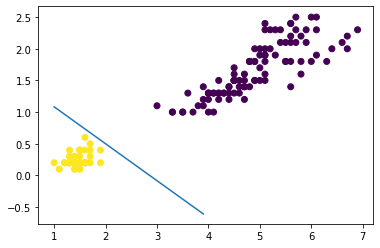

In [9]:
plt.figure()
plt.scatter(X[:,0],X[:,1],c=y2)
a=pct.coef_
b=pct.intercept_
print(a.shape)
print(b.shape)
print(X.shape)
print(y.shape)
print(a)
print(b)
m=-(a[0,0]/a[0,1])
b=-(b[0]/a[0,1])
x=np.arange(1,4,0.1)
plt.plot(x,m*x+b)

### Exercise 2: Sequential Neural Network with MNIST
Build a classifier with keras for the MNIST data set.\
HINT: convert integer values in pixels to floats between 0-1

In [10]:
from tensorflow import keras
import tensorflow as tf

In [11]:
mnist = keras.datasets.mnist

In [12]:
(X,y),(Xt,yt) = mnist.load_data()
print(X.shape,y.shape,Xt.shape,yt.shape)
X=X/255.
Xt=Xt/255.
Xv=X[50001:]
yv=y[50001:]
X=X[:50000]
y=y[:50000]

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [13]:
print(X.shape,y.shape,Xv.shape,yv.shape,Xt.shape,yt.shape)

(50000, 28, 28) (50000,) (9999, 28, 28) (9999,) (10000, 28, 28) (10000,)


5


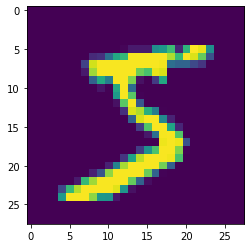

In [14]:
plt.figure()
plt.imshow(X[0])
print(y[0])

Build a sequential fully connected network. Because the output is multiclass we need "softmax" in output.

In [15]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation="relu"))
model.add(keras.layers.Dense(100,activation="relu"))
model.add(keras.layers.Dense(10,activation="softmax"))

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [17]:
# number of parameters for each layer
def nparam(ninput, nneurons):
    return (ninput+1)*nneurons
print(nparam(784,300))
print(nparam(300,100))
print(nparam(100,10))

235500
30100
1010


Use sparse_categorical_crossentropy because:
classes are sparse (1 in 10)
categorical because classes are exclusive
crossentropy is typical for classification

In [18]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [19]:
niter=10
history=model.fit(X,y,epochs=niter,validation_data=(Xv,yv))

Train on 50000 samples, validate on 9999 samples
Epoch 1/10
50000/50000 [==============================] - 4s 72us/sample - loss: 0.6337 - accuracy: 0.8435 - val_loss: 0.3036 - val_accuracy: 0.9157
Epoch 2/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.2968 - accuracy: 0.9155 - val_loss: 0.2451 - val_accuracy: 0.9318
Epoch 3/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.2427 - accuracy: 0.9308 - val_loss: 0.2073 - val_accuracy: 0.9424
Epoch 4/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.2074 - accuracy: 0.9414 - val_loss: 0.1928 - val_accuracy: 0.9462
Epoch 5/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.1817 - accuracy: 0.9481 - val_loss: 0.1672 - val_accuracy: 0.9538
Epoch 6/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.1620 - accuracy: 0.9535 - val_loss: 0.1531 - val_accuracy: 0.9577
Epoch 7/10
50000/50000 [==============================] -

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


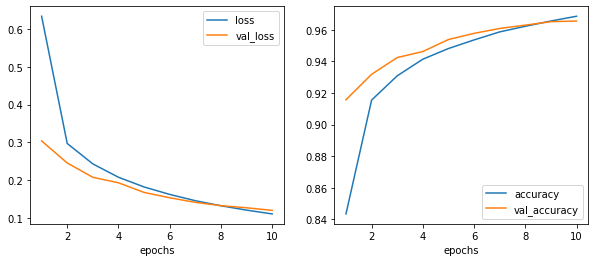

In [20]:
history.params.items
def printhistory(history):
    niter=history.params['epochs']
    print(history.history.keys())
    iter=np.arange(niter)+1
    plt.figure(figsize=(10,4))
    plt.subplot(121)
    plt.plot(iter,history.history['loss'],label='loss')
    plt.plot(iter,history.history['val_loss'],label='val_loss')
    plt.xlabel('epochs')
    plt.legend()
    plt.subplot(122)
    plt.plot(iter,history.history['accuracy'],label='accuracy')
    plt.plot(iter,history.history['val_accuracy'],label='val_accuracy')
    plt.xlabel('epochs')
    plt.legend()
printhistory(history)

In [21]:
model.evaluate(Xt,yt)

10000/10000 [==============================] - 0s 41us/sample - loss: 0.1214 - accuracy: 0.9634


[0.12136966277360917, 0.9634]

In [22]:
model.evaluate(Xt[:3],yt[:3])

3/3 [==============================] - 0s 833us/sample - loss: 0.0047 - accuracy: 1.0000


[0.0047399247996509075, 1.0]

In [23]:
print(yt[:3])

[7 2 1]


(<matplotlib.axes._subplots.AxesSubplot at 0x7fccbc100e50>,
 <matplotlib.image.AxesImage at 0x7fccbc072890>)

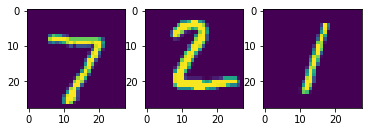

In [24]:
plt.figure()
plt.subplot(131),plt.imshow(Xt[0])
plt.subplot(132),plt.imshow(Xt[1])
plt.subplot(133),plt.imshow(Xt[2])

The evaluate method gives the most probable class. We can see probabilities for each class using predict()

In [25]:
Xnew=Xt[1:20]
ynew=yt[1:20]
yproba=model.predict(Xnew)

In [26]:
print(yproba.round(2))

[[0.   0.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.99 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.96 0.   0.   0.   0.   0.03]
 [0.   0.99 0.   0.   0.   0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.   0.98 0.   0.   0.   0.01 0.  ]
 [0.   0.   0.   0.01 0.   0.   0.   0.   0.   0.99]
 [0.   0.   0.   0.   0.   0.   0.99 0.   0.   0.  ]
 [0.   0.   0.   0.   0.01 0.   0.   0.   0.   0.99]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.98 0.   0.01 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.01 0.   0.99 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]
 [0.   0.   0.   0.01 0.   0.   0.   0.99 0.   0.  ]
 [0.   0.   0.01 0.97 0.   0.   0.   0.   0.02 0.  ]
 [0.   0.   0.   0.   0.99 0.   0.   0.   0.  

In [27]:
yproba2=model.predict_classes(Xnew)
print(yproba2)

[2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]


In [28]:
print(ynew)

[2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [29]:
print(yproba2-ynew)

[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


In [30]:
print(np.argmax(yproba2-ynew))

7


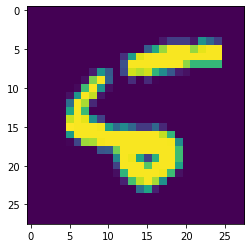

In [31]:
plt.imshow(Xnew[7])

In [34]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [33]:
hidden1 = model.layers[1]
print(hidden1.name)
model.get_layer(hidden1.name) is hidden1

dense


True

In [35]:
weights, biases = hidden1.get_weights()

In [36]:
print(weights.shape, biases.shape)

(784, 300) (300,)


In [39]:
print(weights[0,:10])
print(biases[:10])

[ 0.0157706   0.03256994 -0.00278281  0.03171307 -0.00082048 -0.04324552
  0.07367791  0.06309988 -0.04635281 -0.0072982 ]
[ 0.00651527  0.01749562  0.01010462 -0.00668662  0.01443419 -0.01304636
  0.01493863  0.03267634  0.02305222  0.00830677]


### Exercise 3: Functional API
Write the same problem as exercise 2 but using Functional API

In [63]:
print(X[:].flatten().shape)

(39200000,)


In [64]:
input_ = keras.layers.Input(shape=(28,28))
inputf_ = keras.layers.Flatten(input_shape=[28,28])(input_)
hidden1 = keras.layers.Dense(300, activation="relu")(inputf_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
output = keras.layers.Dense(10,activation="softmax")(hidden2)
model = keras.models.Model(inputs=[input_], outputs=[output])

In [65]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 28, 28)]          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_4 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_5 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [66]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [67]:
model.fit(X,y,epochs=10,validation_data=(Xv,yv))

Train on 50000 samples, validate on 9999 samples
Epoch 1/10
50000/50000 [==============================] - 4s 70us/sample - loss: 0.6538 - accuracy: 0.8321 - val_loss: 0.3114 - val_accuracy: 0.9153
Epoch 2/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.2957 - accuracy: 0.9174 - val_loss: 0.2441 - val_accuracy: 0.9316
Epoch 3/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.2412 - accuracy: 0.9317 - val_loss: 0.2113 - val_accuracy: 0.9430
Epoch 4/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.2067 - accuracy: 0.9409 - val_loss: 0.1890 - val_accuracy: 0.9481
Epoch 5/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.1820 - accuracy: 0.9477 - val_loss: 0.1670 - val_accuracy: 0.9557
Epoch 6/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.1624 - accuracy: 0.9533 - val_loss: 0.1532 - val_accuracy: 0.9579
Epoch 7/10
50000/50000 [==============================] -

### Exercise 4: Subclassing API
Do the same as exercise 2 but with the subclassing API

In [68]:
class mnistexample(keras.models.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.inputf = keras.layers.Flatten(input_shape=[28,28])
        self.hidden1 = keras.layers.Dense(300, activation="relu")
        self.hidden2 = keras.layers.Dense(100, activation="relu")
        self.main_output = keras.layers.Dense(10, activation="softmax")
        
    def call(self, input):
        inputf = self.inputf(input)
        hidden1 = self.hidden1(inputf)
        hidden2 = self.hidden2(hidden1)
        main_output = self.main_output(hidden2)
        return main_output
    


In [69]:
model = mnistexample()

In [77]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [78]:
history=model.fit(X,y, epochs=10, validation_data=(Xv,yv))

Train on 50000 samples, validate on 9999 samples
Epoch 1/10
50000/50000 [==============================] - 4s 70us/sample - loss: 0.1599 - accuracy: 0.9537 - val_loss: 0.1545 - val_accuracy: 0.9563
Epoch 2/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.1438 - accuracy: 0.9590 - val_loss: 0.1397 - val_accuracy: 0.9605
Epoch 3/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.1298 - accuracy: 0.9628 - val_loss: 0.1321 - val_accuracy: 0.9625
Epoch 4/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.1182 - accuracy: 0.9659 - val_loss: 0.1237 - val_accuracy: 0.9648
Epoch 5/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.1081 - accuracy: 0.9694 - val_loss: 0.1188 - val_accuracy: 0.9660
Epoch 6/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.0995 - accuracy: 0.9716 - val_loss: 0.1128 - val_accuracy: 0.9673
Epoch 7/10
50000/50000 [==============================] -

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


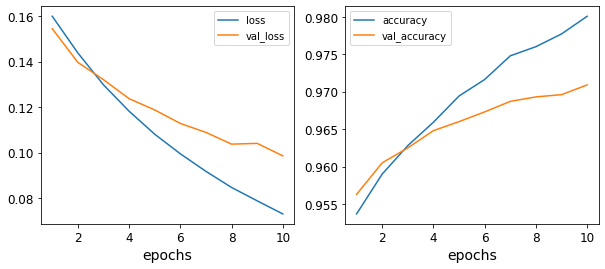

In [79]:
printhistory(history)

In [80]:
model.summary()

Model: "mnistexample"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_2 (Flatten)          multiple                  0         
_________________________________________________________________
dense_6 (Dense)              multiple                  235500    
_________________________________________________________________
dense_7 (Dense)              multiple                  30100     
_________________________________________________________________
dense_8 (Dense)              multiple                  1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [81]:
Xnew=Xt[10:20]
ynew=yt[10:20]
yproba=model.predict(Xnew)
print(yproba.round(2))

[[1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.07 0.   0.92 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]
 [0.   0.   0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.   0.96 0.   0.   0.   0.   0.04 0.  ]
 [0.   0.   0.   0.   1.   0.   0.   0.   0.   0.  ]]


In [82]:
print(ynew)

[0 6 9 0 1 5 9 7 3 4]


In [88]:
# Not sure how to make the model class to inherent the predict_classes method.
#yproba2=model.predict_classes(Xnew)
#print(yproba2)
print(yproba.shape)
print(np.argmax(yproba,axis=1))

(10, 10)
[0 6 9 0 1 5 9 7 3 4]


### Exercise 5 - Regression MLP
Use the california_housing data set we used earlier in the course with linear regression and compare with MLP.

In [40]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [49]:
print(housing.data[0:2])
print(X_train[0:2,:])
print(y_train[0:2])

[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]]
[[-0.19397883 -1.07781319 -0.94338545  0.01485314  0.02073335 -0.57291624
   0.92926047 -1.42215523]
 [ 0.75198318 -1.868895    0.40547793 -0.23327682  1.8614649   0.20516532
  -0.91654738  1.09666969]]
[1.442 1.687]


In [41]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(lr=1e-3))
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))


Train on 11610 samples, validate on 3870 samples
Epoch 1/20
11610/11610 [==============================] - 1s 85us/sample - loss: 2.2671 - val_loss: 3.5776
Epoch 2/20
11610/11610 [==============================] - 1s 58us/sample - loss: 0.8426 - val_loss: 0.8084
Epoch 3/20
11610/11610 [==============================] - 1s 57us/sample - loss: 0.7029 - val_loss: 0.6372
Epoch 4/20
11610/11610 [==============================] - 1s 58us/sample - loss: 0.6520 - val_loss: 0.7086
Epoch 5/20
11610/11610 [==============================] - 1s 58us/sample - loss: 0.6229 - val_loss: 0.5874
Epoch 6/20
11610/11610 [==============================] - 1s 58us/sample - loss: 0.5920 - val_loss: 0.5564
Epoch 7/20
11610/11610 [==============================] - 1s 58us/sample - loss: 0.5691 - val_loss: 0.5289
Epoch 8/20
11610/11610 [==============================] - 1s 59us/sample - loss: 0.5488 - val_loss: 0.5079
Epoch 9/20
11610/11610 [==============================] - 1s 59us/sample - loss: 0.5303 - val_l

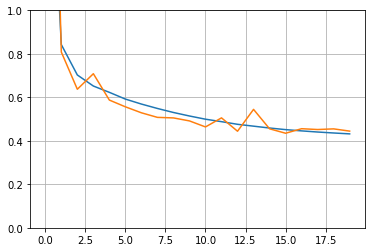

In [42]:
plt.plot(pd.DataFrame(history.history))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [66]:
mse_test = model.evaluate(X_test, y_test)
nsamples=-1
X_new = X_test[:nsamples]
y_new = y_test[:nsamples]
mse_new = model.evaluate(X_new, y_new)
y_pred = model.predict(X_new)
print('predicted',np.round(y_pred.T,2))
print('true      ',np.round(y_new,2))

5159/5159 [==============================] - 0s 34us/sample - loss: 0.4299
predicted [[0.63 1.74 3.13 ... 0.79 1.33 2.74]]
true       [0.48 0.46 5.   ... 0.63 1.18 2.63]


In [51]:
print(mse_test)

0.43003384678862816
